In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def topk_acc(probs, labels, k):
    top_k = np.argsort(probs, axis=1)[:, -k:]
    return float(np.mean(np.any(top_k == np.array(labels).reshape(-1, 1), axis=1)))


In [2]:
df = pd.read_csv('../data/processed/hmm_wind.csv')
df = df.sort_values(['animal_id', 'trayectoria_id', 'date'])
df['date'] = pd.to_datetime(df['date'])

# --- Features heredadas de ML5 ---
df['semana_num']   = df['date'].dt.isocalendar().week.astype(int)
df['step_lag1']    = df.groupby('trayectoria_id')['step_length'].shift(1)
df['bearing_lag1'] = df.groupby('trayectoria_id')['bearing'].shift(1)
df['step_lag2']    = df.groupby('trayectoria_id')['step_length'].shift(2)
df['bearing_lag2'] = df.groupby('trayectoria_id')['bearing'].shift(2)

df['_estado_change'] = df.groupby('trayectoria_id')['estado_hmm'] \
                         .transform(lambda x: (x != x.shift(1)).fillna(True))
df['_episode_id'] = df.groupby('trayectoria_id')['_estado_change'].cumsum()
df['streak_dias'] = df.groupby(['trayectoria_id', '_episode_id']).cumcount() + 1
df['cum_dist_episodio'] = df.groupby(['trayectoria_id', '_episode_id'])['step_length'].cumsum()
df['_cum_bearing_sum'] = df.groupby(['trayectoria_id', '_episode_id'])['bearing'].cumsum()
df['mean_bearing_episodio'] = df['_cum_bearing_sum'] / df['streak_dias']
df['dist_cria']      = (df['lat'] - 60.0).abs()
df['dist_invernada'] = (df['lat'] - 10.0).abs()
df['delta_bearing']  = ((df['bearing'] - df['bearing_lag1'] + 180) % 360) - 180

# --- Nuevos features ML6: viento ERA5 a 850 hPa ---
# u_wind, v_wind, wind_speed, tail_wind, cross_wind ya están en hmm_wind.csv

# Target y centroides
df['target_cell'] = df.groupby('trayectoria_id')['cell_id'].shift(-1)
centroids = df.groupby('cell_id')[['lon','lat']].mean() \
               .rename(columns={'lon':'cell_lon','lat':'cell_lat'})

df_f = df.dropna(subset=['target_cell','step_lag2','bearing_lag2']).copy()

FEATURES = [
    # Posición
    'grid_x', 'grid_y',
    # Movimiento actual
    'step_length', 'bearing', 'turning_angle',
    # Inercia
    'step_lag1', 'bearing_lag1', 'step_lag2', 'bearing_lag2',
    # Episodio
    'streak_dias', 'cum_dist_episodio', 'mean_bearing_episodio',
    # Dirección
    'delta_bearing',
    # Contexto latitudinal
    'dist_cria', 'dist_invernada',
    # Hábitat y temporada
    'veg_low', 'veg_high', 'semana_num',
    # Viento ERA5 a 850 hPa  ← NUEVOS EN ML6
    'u_wind', 'v_wind', 'wind_speed', 'tail_wind', 'cross_wind',
]

print(f'Dataset: {len(df_f)} filas | {len(FEATURES)} features')
print(f'Migración:    {(df_f.estado_hmm==0).sum()} filas')
print(f'Estacionario: {(df_f.estado_hmm==1).sum()} filas')
print(f'\nFeatures nuevas respecto a ML5: u_wind, v_wind, wind_speed, tail_wind, cross_wind')
print(df_f[['u_wind','v_wind','wind_speed','tail_wind','cross_wind']].describe().round(2))


Dataset: 19579 filas | 23 features
Migración:    4217 filas
Estacionario: 15362 filas

Features nuevas respecto a ML5: u_wind, v_wind, wind_speed, tail_wind, cross_wind
         u_wind    v_wind  wind_speed  tail_wind  cross_wind
count  19579.00  19579.00    19579.00   19579.00    19579.00
mean       2.06      0.81        5.76      -0.01       -0.01
std        4.92      4.58        4.11       5.04        4.97
min      -20.96    -25.93        0.01     -28.60      -27.79
25%       -1.09     -2.04        2.85      -2.76       -2.65
50%        1.56      0.45        4.59      -0.05        0.00
75%        4.44      3.21        7.72       2.74        2.66
max       27.67     25.59       31.82      29.53       27.79


In [3]:
Xtr_mig, Xte_mig, ytr_mig_raw, yte_mig_raw = [], [], [], []
Xtr_sta, Xte_sta, ytr_sta_raw, yte_sta_raw = [], [], [], []

for animal, grp in df_f.groupby('animal_id'):
    grp = grp.sort_values('date')
    if len(grp) < 5:
        continue
    cut = int(len(grp) * 0.8)
    train, test = grp.iloc[:cut], grp.iloc[cut:]

    for estado, (Xtr_l, Xte_l, ytr_l, yte_l) in [
        (0, (Xtr_mig, Xte_mig, ytr_mig_raw, yte_mig_raw)),
        (1, (Xtr_sta, Xte_sta, ytr_sta_raw, yte_sta_raw)),
    ]:
        tr_s = train[train['estado_hmm'] == estado]
        te_s = test[test['estado_hmm'] == estado]
        if len(tr_s) >= 3:
            Xtr_l.append(tr_s[FEATURES])
            ytr_l.append(tr_s['target_cell'])
        if len(te_s) >= 1:
            Xte_l.append(te_s[FEATURES + ['next_lat','next_lon']])
            yte_l.append(te_s['target_cell'])

Xtr_mig = pd.concat(Xtr_mig);  ytr_mig_raw = pd.concat(ytr_mig_raw)
Xte_mig = pd.concat(Xte_mig);  yte_mig_raw = pd.concat(yte_mig_raw)
Xtr_sta = pd.concat(Xtr_sta);  ytr_sta_raw = pd.concat(ytr_sta_raw)
Xte_sta = pd.concat(Xte_sta);  yte_sta_raw = pd.concat(yte_sta_raw)

le_mig = LabelEncoder().fit(ytr_mig_raw)
le_sta = LabelEncoder().fit(ytr_sta_raw)

mask_m = yte_mig_raw.isin(le_mig.classes_)
mask_s = yte_sta_raw.isin(le_sta.classes_)

Xte_mig_eval = Xte_mig[mask_m][FEATURES]
yte_mig       = le_mig.transform(yte_mig_raw[mask_m])
Xte_mig_meta  = Xte_mig[mask_m][['next_lat','next_lon']].reset_index(drop=True)

Xte_sta_eval = Xte_sta[mask_s][FEATURES]
yte_sta       = le_sta.transform(yte_sta_raw[mask_s])
Xte_sta_meta  = Xte_sta[mask_s][['next_lat','next_lon']].reset_index(drop=True)

print(f'MIGRACIÓN   — train: {len(Xtr_mig):5d}, test: {len(Xte_mig_eval):4d}, celdas train: {len(le_mig.classes_)}')
print(f'ESTACIONARIO — train: {len(Xtr_sta):5d}, test: {len(Xte_sta_eval):4d}, celdas train: {len(le_sta.classes_)}')


MIGRACIÓN   — train:  3490, test:  526, celdas train: 852
ESTACIONARIO — train: 12099, test: 3004, celdas train: 305


In [4]:
def make_models(n_classes):
    return {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=42, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, learning_rate=0.1,
            objective='multi:softprob', num_class=n_classes,
            eval_metric='mlogloss', random_state=42, verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=200, learning_rate=0.05, num_leaves=31,
            min_child_samples=5, class_weight='balanced',
            random_state=42, verbose=-1
        ),
    }

trained = {'migration': {}, 'stationary': {}}
results = []

for state_name, Xtr, ytr_raw, Xte, yte, le in [
    ('migration',   Xtr_mig, ytr_mig_raw, Xte_mig_eval, yte_mig, le_mig),
    ('stationary',  Xtr_sta, ytr_sta_raw, Xte_sta_eval, yte_sta, le_sta),
]:
    ytr = le.transform(ytr_raw)
    models = make_models(len(le.classes_))
    print(f'\n=== {state_name.upper()} ===')
    for name, model in models.items():
        t0 = time.time()
        model.fit(Xtr, ytr)
        probs = model.predict_proba(Xte)
        preds = np.argmax(probs, axis=1)
        acc = accuracy_score(yte, preds)
        t3  = topk_acc(probs, yte, 3)
        t5  = topk_acc(probs, yte, 5)
        elapsed = time.time() - t0
        trained[state_name][name] = model
        results.append({'Estado': state_name, 'Modelo': name,
                         'Top-1': acc, 'Top-3': t3, 'Top-5': t5,
                         'Tiempo(s)': round(elapsed, 1)})
        print(f'  {name:15s}  Top-1={acc:.4f}  Top-3={t3:.4f}  Top-5={t5:.4f}  ({elapsed:.1f}s)')

print('\n--- TABLA COMPLETA ---')
print(pd.DataFrame(results).to_string(index=False))



=== MIGRATION ===
  Random Forest    Top-1=0.4163  Top-3=0.6027  Top-5=0.6578  (11.7s)
  XGBoost          Top-1=0.4297  Top-3=0.6065  Top-5=0.6540  (34.4s)
  LightGBM         Top-1=0.0856  Top-3=0.0970  Top-5=0.1084  (35.1s)

=== STATIONARY ===
  Random Forest    Top-1=0.8838  Top-3=0.9544  Top-5=0.9601  (12.0s)
  XGBoost          Top-1=0.8795  Top-3=0.9451  Top-5=0.9554  (34.4s)
  LightGBM         Top-1=0.4098  Top-3=0.4764  Top-5=0.4867  (17.1s)

--- TABLA COMPLETA ---
    Estado        Modelo    Top-1    Top-3    Top-5  Tiempo(s)
 migration Random Forest 0.416350 0.602662 0.657795       11.7
 migration       XGBoost 0.429658 0.606464 0.653992       34.4
 migration      LightGBM 0.085551 0.096958 0.108365       35.1
stationary Random Forest 0.883822 0.954394 0.960053       12.0
stationary       XGBoost 0.879494 0.945073 0.955393       34.4
stationary      LightGBM 0.409787 0.476365 0.486684       17.1


=== ERROR GEOGRÁFICO (Random Forest) ===

MIGRACIÓN (n=526)
  p50:    36.8 km
  p75:   107.3 km
  p90:   258.4 km
  p95:   581.2 km
  media:  128.9 km
  ≤50km: 57.4%  ≤100km: 73.6%  ≤200km: 85.6%

ESTACIONARIO (n=3,004)
  p50:     5.5 km
  p75:    10.9 km
  p90:    20.1 km
  p95:    30.9 km
  media:   12.7 km
  ≤50km: 97.6%  ≤100km: 98.3%  ≤200km: 99.3%


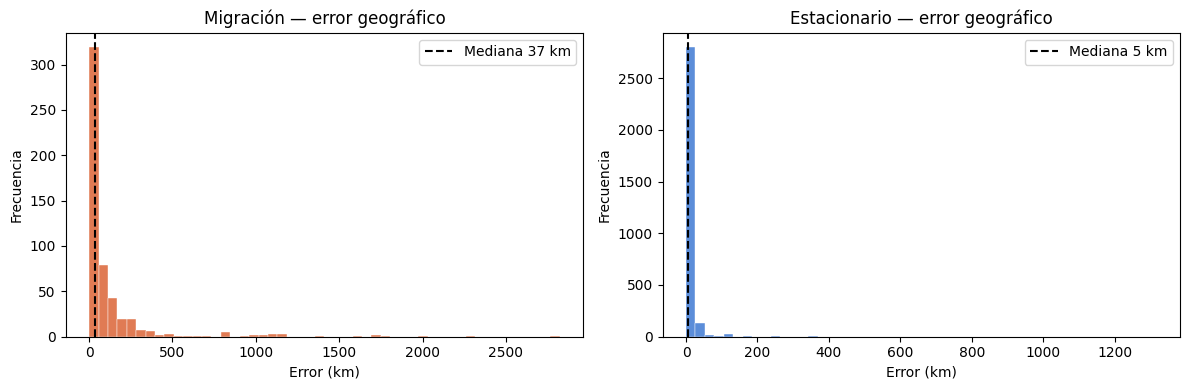

In [5]:
rf_mig = trained['migration']['Random Forest']
rf_sta = trained['stationary']['Random Forest']

def geo_error_km(model, le, Xte, meta_df, centroids_df):
    pred_cells = le.inverse_transform(model.predict(Xte))
    errors = []
    for pred_cell, true_lat, true_lon in zip(
            pred_cells, meta_df['next_lat'], meta_df['next_lon']):
        if pred_cell not in centroids_df.index:
            continue
        p_lat = centroids_df.loc[pred_cell, 'cell_lat']
        p_lon = centroids_df.loc[pred_cell, 'cell_lon']
        errors.append(haversine_km(true_lat, true_lon, p_lat, p_lon))
    return np.array(errors)

err_mig = geo_error_km(rf_mig, le_mig, Xte_mig_eval, Xte_mig_meta, centroids)
err_sta = geo_error_km(rf_sta, le_sta, Xte_sta_eval, Xte_sta_meta, centroids)

def print_error_stats(name, errors):
    print(f'\n{name} (n={len(errors):,})')
    for p in [50, 75, 90, 95]:
        print(f'  p{p:2d}: {np.percentile(errors, p):7.1f} km')
    print(f'  media: {errors.mean():6.1f} km')
    print(f'  ≤50km: {(errors<=50).mean()*100:.1f}%  ≤100km: {(errors<=100).mean()*100:.1f}%  ≤200km: {(errors<=200).mean()*100:.1f}%')

print('=== ERROR GEOGRÁFICO (Random Forest) ===')
print_error_stats('MIGRACIÓN',    err_mig)
print_error_stats('ESTACIONARIO', err_sta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, errors, title, color in zip(
        axes, [err_mig, err_sta],
        ['Migración', 'Estacionario'], ['#e07b54', '#5b8dd9']):
    ax.hist(errors, bins=50, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(np.median(errors), color='black', linestyle='--',
               label=f'Mediana {np.median(errors):.0f} km')
    ax.set_title(f'{title} — error geográfico')
    ax.set_xlabel('Error (km)'); ax.set_ylabel('Frecuencia'); ax.legend()
plt.tight_layout()
plt.savefig('../img/ml6_geo_error.png', dpi=120, bbox_inches='tight')
plt.show()


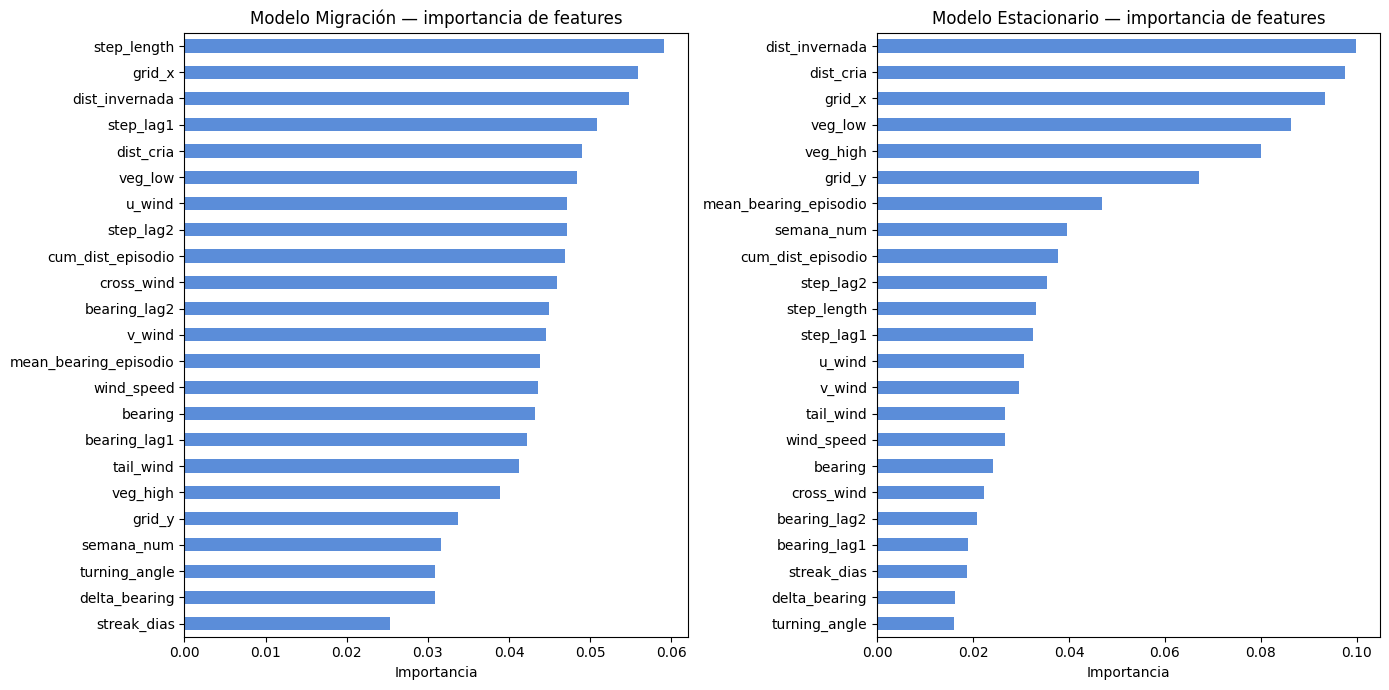


Top-8 features — MIGRACIÓN:
step_length       0.059055
grid_x            0.055929
dist_invernada    0.054816
step_lag1         0.050836
dist_cria         0.049034
veg_low           0.048437
u_wind            0.047144
step_lag2         0.047111

Top-8 features — ESTACIONARIO:
dist_invernada           0.099816
dist_cria                0.097472
grid_x                   0.093336
veg_low                  0.086285
veg_high                 0.079921
grid_y                   0.067147
mean_bearing_episodio    0.046954
semana_num               0.039623


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, model, title in zip(axes, [rf_mig, rf_sta],
                             ['Modelo Migración', 'Modelo Estacionario']):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp.plot.barh(ax=ax, color='#5b8dd9')
    ax.set_title(title + ' — importancia de features')
    ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('../img/ml6_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

for state_name, model in [('MIGRACIÓN', rf_mig), ('ESTACIONARIO', rf_sta)]:
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    print(f'\nTop-8 features — {state_name}:')
    print(imp.head(8).to_string())


In [7]:
rf_mig_r = [r for r in results if r['Estado']=='migration'  and r['Modelo']=='Random Forest'][0]
rf_sta_r = [r for r in results if r['Estado']=='stationary' and r['Modelo']=='Random Forest'][0]

tabla = pd.DataFrame([
    {'Versión': 'ML3 — modelo único',          'Estado': 'Migración',    'Top-1': 0.4795, 'Top-3': 0.6370, 'Top-5': 0.7021},
    {'Versión': 'ML3 — modelo único',          'Estado': 'Estacionario', 'Top-1': 0.8724, 'Top-3': 0.9271, 'Top-5': 0.9324},
    {'Versión': 'ML4 — separado+lag1',         'Estado': 'Migración',    'Top-1': 0.4448, 'Top-3': 0.6420, 'Top-5': 0.6926},
    {'Versión': 'ML4 — separado+lag1',         'Estado': 'Estacionario', 'Top-1': 0.8919, 'Top-3': 0.9519, 'Top-5': 0.9571},
    {'Versión': 'ML5 — features extendidas',   'Estado': 'Migración',    'Top-1': 0.4335, 'Top-3': 0.6369, 'Top-5': 0.6939},
    {'Versión': 'ML5 — features extendidas',   'Estado': 'Estacionario', 'Top-1': 0.8981, 'Top-3': 0.9587, 'Top-5': 0.9697},
    {'Versión': 'ML6 — +viento ERA5',          'Estado': 'Migración',    'Top-1': rf_mig_r['Top-1'], 'Top-3': rf_mig_r['Top-3'], 'Top-5': rf_mig_r['Top-5']},
    {'Versión': 'ML6 — +viento ERA5',          'Estado': 'Estacionario', 'Top-1': rf_sta_r['Top-1'], 'Top-3': rf_sta_r['Top-3'], 'Top-5': rf_sta_r['Top-5']},
])

tabla[['Top-1','Top-3','Top-5']] = tabla[['Top-1','Top-3','Top-5']].map(lambda x: f'{x:.4f}')
print('=== COMPARATIVA COMPLETA ML3 → ML6 (Random Forest) ===')
print(tabla.to_string(index=False))


=== COMPARATIVA COMPLETA ML3 → ML6 (Random Forest) ===
                  Versión       Estado  Top-1  Top-3  Top-5
       ML3 — modelo único    Migración 0.4795 0.6370 0.7021
       ML3 — modelo único Estacionario 0.8724 0.9271 0.9324
      ML4 — separado+lag1    Migración 0.4448 0.6420 0.6926
      ML4 — separado+lag1 Estacionario 0.8919 0.9519 0.9571
ML5 — features extendidas    Migración 0.4335 0.6369 0.6939
ML5 — features extendidas Estacionario 0.8981 0.9587 0.9697
       ML6 — +viento ERA5    Migración 0.4163 0.6027 0.6578
       ML6 — +viento ERA5 Estacionario 0.8838 0.9544 0.9601
